# Resolucao do sudoku com metaheuristicas

In [68]:
#@title Instalar lib
%pip install py-sudoku
%pip install numpy
%pip install matplotlib
%pip install pillow

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Lademir Júnior\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Lademir Júnior\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Lademir Júnior\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Lademir Júnior\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [2]:
#@title Funcoes auxiliares
import numpy as np
from typing import List
import math

def read_file(caminho, size=3) -> List[List[int]]:
  with open(caminho, 'r') as arquivo:
    linhas = arquivo.readlines()  # Ler todas as linhas do arquivo

  puzzle: List[List[int]] = []

  # Processar cada linha e criar a matriz
  for linha in linhas:
      valores_str = linha.strip()[1:-1].split(", ")  # Remover os colchetes e separar os valores pelo separador (', ')
      numeros = []

      for val in valores_str:
        if val == 'None':
          numeros.append(None)
          pass
        else:
          numeros.append(int(val))
          pass

      puzzle.append(numeros)

  # puzzle = Sudoku(size, size, board=puzzle)

  return puzzle





## Geracao de instacias de sudoku

Utilizando biblioteca py-sudoku para geracao de instancias

https://github.com/jeffsieu/py-sudoku

* Para gerar quebra-cabecas diferentes, necessario passar seeds diferentes para cada instancia, para isso, utilizo a lib random para gerar um inteiro aleatorio.




In [ ]:
from sudoku import Sudoku
import random

puzzle = Sudoku(3, seed=random.randint(1, 100)).difficulty(0.9)

print(puzzle.board)

[[None, None, None, None, None, None, None, None, None], [None, None, None, None, None, None, 3, None, 9], [None, None, None, None, 9, None, None, None, None], [None, 7, None, None, None, None, None, None, None], [None, None, None, None, None, 2, None, None, None], [None, None, None, None, None, None, None, 5, None], [None, 5, 3, None, None, None, None, None, None], [None, None, None, None, None, None, None, None, None], [None, None, None, None, None, None, None, None, 1]]


### Criacao das instancias

* 300 faceis
* 300 medias
* 300 dificeis

Obs:

In [3]:
#@title Criar instancias
import random
from sudoku import Sudoku
import os

folder_path = './instancias'

easy = 1 - 0.43
medium = 1 - 0.37
hard = 1 - 0.20

def make_easy_instances():
  for i in range(300):
    os.makedirs(folder_path + '/facil (0.3)', exist_ok=True)
    file_path = os.path.join(folder_path + '/facil (0.3)', f'instancia{i}.txt')
    with open(file_path, 'w') as f:
      puzzle = Sudoku(3, seed=i).difficulty(easy)
      for row in puzzle.board:
        f.write(str(row) + '\n')
    # print('[ * ] Finalizou a criacao das instancias faceis')

    # os.makedirs(folder_path + '/solution' + '/facil', exist_ok=True)
    # file_path_solved = os.path.join(folder_path + '/solution' + '/facil', f'instancia{i}.txt')
    # with open(file_path_solved, 'w') as f:
    #   for row in puzzle.solve().board:
    #     f.write(str(row) + '\n')

  print(f'[ * ] Finalizou criacao de instancias faceis')

def make_medium_instances():
  for i in range(300):
    os.makedirs(folder_path + '/medio (0.6)', exist_ok=True)
    file_path = os.path.join(folder_path + '/medio (0.6)', f'instancia{i}.txt')
    with open(file_path, 'w') as f:
      puzzle = Sudoku(3, seed=i).difficulty(medium)
      for row in puzzle.board:
        f.write(str(row) + '\n')
    # print('[ * ] Finalizou a criacao das instancias medias')

    # os.makedirs(folder_path + '/solution' + '/medio', exist_ok=True)
    # file_path_solved = os.path.join(folder_path + '/solution' + '/medio', f'instancia{i}.txt')
    # with open(file_path_solved, 'w') as f:
    #   for row in puzzle.solve().board:
    #     f.write(str(row) + '\n')

    # print(f'Terminou a iteracao: [{i}]')

  print(f'[ * ] Finalizou criacao de instancias medias')
def make_hard_instances():
  for i in range(300):
    os.makedirs(folder_path + '/dificil (0.9)', exist_ok=True)
    file_path = os.path.join(folder_path + '/dificil (0.9)', f'instancia{i}.txt')
    with open(file_path, 'w') as f:
      puzzle = Sudoku(3, seed=random.randint(1,300)).difficulty(hard)
      for row in puzzle.board:
        f.write(str(row) + '\n')
    # print('[ * ] Finalizou a criacao das instancias dificeis')

    # os.makedirs(folder_path + '/solution' + '/dificil', exist_ok=True)
    # file_path_solved = os.path.join(folder_path + '/solution' + '/dificil', f'instancia{i}.txt')
    # with open(file_path_solved, 'w') as f:
    #   for row in puzzle.solve().board:
    #     f.write(str(row) + '\n')

    # print(f'Terminou a iteracao: [{i}]')
  print(f'[ * ] Finalizou criacao de instancias dificeis')
make_easy_instances()
make_medium_instances()
make_hard_instances()

[ * ] Finalizou criacao de instancias faceis
[ * ] Finalizou criacao de instancias medias
[ * ] Finalizou criacao de instancias dificeis


In [ ]:
#@title Exemplo de leitura de uma instancia

nome_arquivo = "./instancias/facil (0.3)/instancia0.txt"

# Abrir o arquivo em modo de leitura
with open(nome_arquivo, 'r') as arquivo:
    linhas = arquivo.readlines()  # Ler todas as linhas do arquivo

puzzle = []

# Processar cada linha e criar a matriz
for linha in linhas:
    valores_str = linha.strip()[1:-1].split(", ")  # Remover os colchetes e separar os valores pelo separador (', ')
    numeros = []

    for val in valores_str:
      if val == 'None':
        numeros.append(None)
        pass
      else:
        numeros.append(int(val))
        pass

    puzzle.append(numeros)

puzzle = Sudoku(3, 3, board=puzzle)
puzzle.show_full()

puzzle.solve().show_full()


---------------------------
9x9 (3x3) SUDOKU PUZZLE
Difficulty: 0.57
---------------------------
+-------+-------+-------+
| 9     | 2   4 |       |
| 3     | 5 8   |   9 7 |
| 8   5 |   3   |   6   |
+-------+-------+-------+
| 7 8   | 4   2 | 9   3 |
| 6     | 7 5   | 1     |
| 4 5   |       |       |
+-------+-------+-------+
|     8 |       | 5 2   |
|   4   |   7 5 |   3   |
| 5   9 | 6   8 |       |
+-------+-------+-------+

        

---------------------------
9x9 (3x3) SUDOKU PUZZLE
Difficulty: SOLVED
---------------------------
+-------+-------+-------+
| 9 6 7 | 2 1 4 | 3 8 5 |
| 3 1 4 | 5 8 6 | 2 9 7 |
| 8 2 5 | 9 3 7 | 4 6 1 |
+-------+-------+-------+
| 7 8 1 | 4 6 2 | 9 5 3 |
| 6 9 2 | 7 5 3 | 1 4 8 |
| 4 5 3 | 8 9 1 | 6 7 2 |
+-------+-------+-------+
| 1 7 8 | 3 4 9 | 5 2 6 |
| 2 4 6 | 1 7 5 | 8 3 9 |
| 5 3 9 | 6 2 8 | 7 1 4 |
+-------+-------+-------+

        


## Funcao de avaliacao

Quantidade de numeros repetidos em cada linha e coluna

In [3]:
#@title Fitness fn
from typing import List

def count_duplicates(matrix):
    row_counts = []
    col_counts = []
    num_rows = len(matrix)
    num_cols = len(matrix[0])

    for i in range(num_rows):
        row_count = {}
        for j in range(num_cols):
            element = matrix[i][j]
            if element in row_count:
                row_count[element] += 1
            else:
                row_count[element] = 0
        row_duplicates = {k: v for k, v in row_count.items() if v >= 1}
        row_counts.append(row_duplicates)

    for j in range(num_cols):
        col_count = {}
        for i in range(num_rows):
            element = matrix[i][j]
            if element in col_count:
                col_count[element] += 1
            else:
                col_count[element] = 0
        col_duplicates = {k: v for k, v in col_count.items() if v >= 1}
        col_counts.append(col_duplicates)

    return row_counts, col_counts

def fitness(board: List[List[int]]) -> int:
  fit = 0
  row_duplicates, col_duplicates = count_duplicates(board)

  for row_duplicate in row_duplicates:
    for el in row_duplicate.items():
      if el[0] is not None:
        fit += el[1]

  for col_duplicate in col_duplicates:
    for el in col_duplicate.items():
      if el[0] is not None:
        fit += el[1]

  return fit

## Geracao da solucao inicial

* Garante que cada subgrade estara atendendo as restricoes, uma vez que cada uma possuira numeros de 1 a n sem repeticoes.
* Tambem retorna uma matriz em que possui como True a posicao das celulas fixas, para que nao sejam alteradas conforme o algoritmo for executado

## Classe SudokuSolver

* possui metodos para facilitar o utilizacao dos algoritmos, como a geracao da vizinhanca e solucoes iniciais

In [4]:
#@title Classe SudokuSolver para auxiliar
from sudoku import Sudoku
from typing import List, Set, Tuple
import random
import numpy as np

class SudokuSolver:
  def __init__(self, lines: int, cols: int, board: List[List[int]]):
    self.lines = lines ** 2
    self.cols = cols ** 2
    self.sub_lines = lines
    self.sub_cols = cols
    self.board: List[List[int]] = board

    self.fixed_cells = self.detect_fixed_cells()

    self.g = {}
    self.r = {}
    self.c = {}

  def copy(self):
        # Cria uma nova instância da classe com os mesmos atributos
        new_instance = type(self)(
            self.sub_lines, self.sub_cols, [row[:] for row in self.board]
        )
        new_instance.fixed_cells = np.copy(self.fixed_cells)
        new_instance.g = self.g.copy()
        new_instance.r = self.r.copy()
        new_instance.c = self.c.copy()
        new_instance.sub_lines = self.sub_lines
        new_instance.sub_cols = self.sub_cols

        return new_instance

  def rows(self):
    if len(self.r) == 0 or True:
      for i in range(self.lines):
        self.r[i] = self.board[i]
    return self.r

  def columns(self):
    if len(self.c) == 0 or True:
      for j in range(self.cols):
        self.c[j] = []
        for i in range(self.lines):
          self.c[j].append(self.board[i][j])
    return self.c


  def grids(self):
    if len(self.g) == 0 or True:
      grid_line = int(self.lines ** 0.5)
      grid_cols = int(self.cols ** 0.5)

      for k in range(grid_line * grid_cols):
          grid = []
          start_line = (k // grid_cols) * grid_line
          start_col = (k % grid_cols) * grid_cols

          for i in range(grid_line):
              for j in range(grid_cols):
                  grid.append((self.board[start_line + i][start_col + j], (start_line + i, start_col + j)))

          self.g[k] = grid

    return self.g

  def show(self):
    print(f'Fitness: {self.fit()}')
    for row in self.board:
      print(row)

  def detect_fixed_cells(self):
        fixed_cells = np.zeros((self.lines, self.cols), dtype=bool)

        for i in range(self.lines):
            for j in range(self.cols):
                if self.board[i][j] != None:
                    fixed_cells[i][j] = True

        return fixed_cells

  def fitness(self, board = None):
    return fitness(self.board) if board is None else fitness(board)

  def fit(self):
    fit = 0

    rows = self.rows()
    cols = self.columns()
    # grids = self.grids()

    row_counts = []
    col_counts = []
    # grid_counts = []

    for i, row in enumerate(rows):
      row_count = {}
      for j, el in enumerate(rows[row]):
        if el in row_count:
          row_count[el] += 1
        else:
          row_count[el] = 0
      row_duplicates = {k: v for k, v in row_count.items() if v >= 1}
      row_counts.append(row_duplicates)

    for i, col in enumerate(cols):
      col_count = {}
      for j, el in enumerate(cols[col]):
        if el in col_count:
          col_count[el] += 1
        else:
          col_count[el] = 0
      col_duplicates = {k: v for k, v in col_count.items() if v >= 1}
      col_counts.append(col_duplicates)

    # for i, grid in enumerate(grids):
    #   grid_count = {}
    #   for j, el in enumerate(grids[grid]):
    #     if el in grid_count:
    #       grid_count[el] += 1
    #     else:
    #       grid_count[el] = 0
    #   grid_duplicates = {k: v for k, v in grid_count.items() if v >= 1}
    #   grid_counts.append(grid_duplicates)



    for row_duplicate in row_counts:
      for el in row_duplicate.items():
        if el[0] is not None:
          fit += el[1]

    for col_duplicate in col_counts:
      for el in col_duplicate.items():
        if el[0] is not None:
          fit += el[1]

    # for grid_duplicate in grid_counts:
    #   for el in grid_duplicate.items():
    #     if el[0] is not None:
    #       fit += el[1]

    return fit
  
  def random_solution(self):
    grids = self.grids()
    board = [row[:] for row in self.board]

    for i in range(len(grids)):
      digits = {x for x in range(1, self.sub_lines * self.sub_cols + 1)}
      #el = (elemento, coordenada[i][j] na board)
      for j in grids[i]:
        digits.discard(j[0])
        # print(f'Descartou: {j}')
      for j, el in enumerate(grids[i]):
        if el[0] is None:
          # print(f'Possiveis digitos: {digits}')
          add_digit = random.choice(list(digits))
          # print(f'Digitos escolhido: {add_digit}')
          digits.discard(add_digit)
          board[el[1][0]][el[1][1]] = add_digit

    self.board = board
    return board

  def have_duplicates_row_col(self, coord, digit, board_d=None):
    count = 0
    el = digit
    board = []

    if board_d is None:
      board = self.board
    else:
      board = board_d

    for i in range(len(board)):
      # print(f'self.board[{i}][{coord[1]}] = {board[i][coord[1]]} == {el}')
      if board[i][coord[1]] == el:
        count += 1
    for i in range(len(board)):
      # print(f'self.board[{coord[0]}][{i}] = {board[coord[0]][i]} == {el}')
      if board[coord[0]][i] == el:
        count += 1
    return count

  def greedy_solution(self):
    grids = self.grids()
    board = [row[:] for row in self.board]

    for i in range(len(grids)):
      # print(f'Iteracao [{i}]')
      digits = {x for x in range(1, self.sub_lines * self.sub_cols + 1)}
      # retirando os digitos que ja estao no grid
      for j in grids[i]:
        digits.discard(j[0])
      # print(f'Digitos possiveis: {digits}')
      for cel in grids[i]:
        if cel[0] is not None:
          continue
        # print(f'Olhando para celula {cel}')
        min_el = None
        min_cel_cost = 100
        for digit in digits:
          d_cost = self.have_duplicates_row_col((cel[1][0],cel[1][1]), digit, board_d=board)
          # print(f'Testando digitos: {digit}, tem custo de {d_cost}')
          if d_cost < min_cel_cost:
            min_el = digit
            min_cel_cost = d_cost
        digits.discard(min_el)
        # print(f'digito escolhido foi o {min_el} para ser co/ocar no [{cel[1][0]}][{cel[1][1]}]')
        board[cel[1][0]][cel[1][1]] = min_el
      self.board = board
    return board


# troca aleatoria de numeros de uma celula aleatoria
  def make_any_neighboor(self):
    grids = self.grids()
    board = [row[:] for row in self.board]
    # Selecionar uma célula aleatória
    row = random.randint(0, self.lines - 1)
    col = random.randint(0, self.cols - 1)

    while self.fixed_cells[row][col] is False:
      row = random.randint(0, self.lines - 1)
      col = random.randint(0, self.cols - 1)

    board[row][col] = random.randint(1, self.sub_lines * self.sub_cols)
    return board

  # gera um vizinho trocando dois valores nao fixos de uma subgrade aleatoria
  def make_neighboor_exchange(self):
    grids = self.grids()
    board = [row[:] for row in self.board]

    random_grid_index = random.randint(0, len(grids) - 1)
    random_grid = grids[random_grid_index]

    grid_coords = set()

    for el in range(len(random_grid)):
      if self.fixed_cells[random_grid[el][1][0]][random_grid[el][1][1]] == False:
        grid_coords.add(random_grid[el][1])

    # print(grid_coords)
    el1 = random.choice(list(grid_coords))
    grid_coords.discard(el1)
    el2 = random.choice(list(grid_coords))

    board[el1[0]][el1[1]], board[el2[0]][el2[1]] = board[el2[0]][el2[1]], board[el1[0]][el1[1]]

    return board

  # gera todos trocando dois valores aleatorios nao fixos de cada subgrade
  def make_all_grids_neighboor_exchange(self):
    grids = self.grids()

    neighboorhood = []

    for i in range(len(grids)):

      board = [row[:] for row in self.board]
      grid = grids[i]

      grid_coords = set()

      for el in range(len(grid)):
        if self.fixed_cells[grid[el][1][0]][grid[el][1][1]] == False:
          grid_coords.add(grid[el][1])

      if len(grid_coords) > 1:
        # print(grid_coords)
        el1 = random.choice(list(grid_coords))
        grid_coords.discard(el1)
        el2 = random.choice(list(grid_coords))

        board[el1[0]][el1[1]], board[el2[0]][el2[1]] = board[el2[0]][el2[1]], board[el1[0]][el1[1]]
        neighboorhood.append(board)
    return neighboorhood


  # retornar todos os vizinhos nesse caso para escol
  def make_neighboorhood_inversion_row(self):

    neighboorhood: List[SudokuSolver] = []

    for row_index, row in enumerate(self.board):
      board = [row[:] for row in self.board]
      number: List[int] = []
      for col_index, el in enumerate(board[row_index]):
        if self.fixed_cells[row_index][col_index] == False:
          number.append(board[row_index][col_index])
          board[row_index][col_index] = None
      for col_index, el in enumerate(board[row_index]):
        if el is None:
          board[row_index][col_index] = number.pop()

      neighboorhood.append(SudokuSolver(3, 3, board))
    return neighboorhood


# Main

In [5]:
import matplotlib.pyplot as plt

def draw_sudoku(solver: SudokuSolver):
    matrix = solver.board
    plt.figure(figsize=(6, 6))
    ax = plt.gca()
    ax.set_xticks(np.arange(0, 9, 1))
    ax.set_yticks(np.arange(0, 9, 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(color='black', linestyle='-', linewidth=2)
    ax.set_title(f'Fitness: {solver.fit()}')

    for i in range(9):
        for j in range(9):
            value = matrix[i][j]
            if value != 0:
                if value is None:
                    ax.text(j + 0.5, 8 - i + 0.5, ' ', va='center', ha='center', fontsize=18)
                else:
                    if solver.fixed_cells[i][j]:
                        ax.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18, color='black', bbox=dict(facecolor='lightblue', edgecolor='none'))
                    else:
                        if solver.have_duplicates_row_col((i,j), matrix[i][j], matrix) > 2:
                            ax.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18, bbox=dict(facecolor='red', edgecolor='none'))
                        else:
                            ax.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18)

    for i in range(0, 10, 3):
        ax.axhline(i, color='black', linewidth=3)
        ax.axvline(i, color='black', linewidth=3)

    for i in range(1, 9):
        if i % 3 == 0:
            ax.axhline(i, color='black', linewidth=2)
            ax.axvline(i, color='black', linewidth=2)
        else:
            ax.axhline(i, color='gray', linewidth=1)
            ax.axvline(i, color='gray', linewidth=1)

    plt.show()


In [6]:
#@title Simulated Anneling for solving sudoku
from copy import deepcopy
import random
from math import exp
from IPython.display import clear_output

def sudokuSA(solver: SudokuSolver, SA_MAX=2500, temperature=140, cooling_rate=0.80):
    best_state = solver.copy()
    b_fit = best_state.fit()
    iterT = 0
    temp = temperature

    curr_state = solver.copy()

    freezing_temperature = 0.5

    while temperature > freezing_temperature:
        for i in range(SA_MAX):
            iterT += 1
            v = curr_state.make_all_grids_neighboor_exchange()

            v_best = []
            v_best_fit = 100

            for j in v:
                j_fit = fitness(j)
                if j_fit < v_best_fit:
                    v_best = [row[:] for row in j]
                    v_best_fit = j_fit

            vn = SudokuSolver(3, 3, v_best)
            vn.fixed_cells = curr_state.fixed_cells

            c_fit = curr_state.fit()
            v_fit = vn.fit()

            if v_fit < c_fit:
                curr_state = vn.copy()
                c_fit = v_fit
                if c_fit < b_fit:
                    best_state = curr_state.copy()
                    b_fit = c_fit
                    # draw_sudoku(curr_state)
                    # clear_output(wait=True)
            elif random.random() < exp((curr_state.fit() - vn.fit()) / temperature) and c_fit != v_fit:
                curr_state = vn.copy()
                c_fit = v_fit

            if c_fit == 0:
                break
        if b_fit == 0:
            break
        temperature *= cooling_rate

    return best_state


In [7]:
#@title Simulated Annealing com grafico
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython.display import display, clear_output

def sudokuSA_graf(solver: SudokuSolver, SA_MAX=2500, temperature=140, cooling_rate=0.80):
    best_state = solver.copy()
    b_fit = best_state.fit()
    iterT = 0
    temp = temperature

    curr_state = solver.copy()

    freezing_temperature = 0.5

    fitness_values = []  # Lista para armazenar os valores de fitness em cada iteração
    time_values = []  # Lista para armazenar o tempo em cada iteração

    fig, ax = plt.subplots(figsize=(12, 6))  # Aumenta o tamanho do gráfico
    ax.set_xlabel('Número da Iteração')
    ax.set_ylabel('Valor da Solução Corrente')
    ax.set_title(f'Evolução do Valor da Solução Corrente\nTemperatura: {temperature:.2f}')

    iteration_text = ax.text(0.5, -0.15, '', transform=ax.transAxes, ha='center')
    time_text = ax.text(0.5, -0.25, '', transform=ax.transAxes, ha= 'center')

    start_time = time.time()

    while temperature > freezing_temperature:
        for i in range(SA_MAX):
            iterT += 1
            v = curr_state.make_all_grids_neighboor_exchange()

            v_best = []
            v_best_fit = 100

            for j in v:
                j_fit = fitness(j)
                if j_fit < v_best_fit:
                    v_best = [row[:] for row in j]
                    v_best_fit = j_fit

            vn = SudokuSolver(3, 3, v_best)
            vn.fixed_cells = curr_state.fixed_cells

            c_fit = curr_state.fit()
            v_fit = vn.fit()

            if v_fit < c_fit:
                curr_state = vn.copy()
                c_fit = v_fit
                if c_fit < b_fit:
                    best_state = curr_state.copy()
                    b_fit = c_fit
                    # draw_sudoku(best_state, True)
            elif np.random.random() < np.exp((curr_state.fit() - vn.fit()) / temperature) and c_fit != v_fit:
                curr_state = vn.copy()
                c_fit = v_fit

            fitness_values.append(c_fit)  # Adiciona o valor de fitness na lista
            if c_fit == 0:
                print(f'c-fit == 0')
                break
        if b_fit == 0:
            break
        temperature *= cooling_rate
        print(f'Temperature: {temperature:.2f}')
        ax.set_title(f'Evolução do Valor da Solução Corrente\nTemperatura: {temperature:.2f}')
        iteration_text.set_text(f'Iteração Total: {iterT}   |   Iteração dentro da Temperatura: {i+1}')

    end_time = time.time()
    total_time = end_time - start_time
    time_values = [total_time] * len(fitness_values)

    time_text.set_text(f'Tempo total: {total_time:.5f}s')
    SA_MAX = len(fitness_values)  # Update SA_MAX to the actual number of iterations

    iteration_text.set_text(f'Iteração Total: {iterT}   |   Iteração dentro da Temperatura: {i+1}')
    # Encontra o índice do menor valor na iteração corrente
    min_index = np.argmin(fitness_values)

    ax.plot(range(1, SA_MAX + 1), fitness_values, 'b-', label='Valor da Solução Corrente')  # Plota o gráfico atualizado
    # ax.plot(range(1, SA_MAX + 1), time_values, 'r-', label='Tempo (s)')  # Plota o tempo
    ax.set_xlim([1, SA_MAX])  # Define os limites do eixo x
    ax.set_ylim([0, max(fitness_values) + 10])  # Define os limites do eixo y

    # Plota o ponto fixo no menor valor da iteração corrente
    ax.scatter(min_index + 1, fitness_values[min_index], color='r')

    # Anota o valor do menor elemento no gráfico
    ax.annotate(f'Menor: {fitness_values[min_index]}', xy=(min_index + 1, fitness_values[min_index]),
                xytext=(min_index + 1, fitness_values[min_index] - 10),
                arrowprops=dict(facecolor='black', arrowstyle='->'))

    ax.legend()

    plt.show()
    plt.close(fig)  # Fecha a figura
    return best_state


In [15]:
import cv2
import numpy as np

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def draw_sudoku_for_video(solver1: SudokuSolver, solver2: SudokuSolver, iterT):
    matrix1 = solver1.board
    matrix2 = solver2.board

    fig = plt.figure(figsize=(12, 6))

    ax1 = plt.subplot(1, 2, 1)
    ax1.set_xticks(np.arange(0, 9, 1))
    ax1.set_yticks(np.arange(0, 9, 1))
    ax1.set_xticklabels([])
    ax1.set_yticklabels([])
    ax1.grid(color='black', linestyle='-', linewidth=2)
    ax1.set_title('Melhor Solução')

    for i in range(9):
        for j in range(9):
            value = matrix1[i][j]
            if value != 0:
                if value is None:
                    ax1.text(j + 0.5, 8 - i + 0.5, ' ', va='center', ha='center', fontsize=18)
                else:
                    if solver1.fixed_cells[i][j]:
                        ax1.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18,
                                color='black', bbox=dict(facecolor='lightblue', edgecolor='none'))
                    else:
                        if solver1.have_duplicates_row_col((i, j), matrix1[i][j], matrix1) > 2:
                            ax1.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18,
                                    bbox=dict(facecolor='red', edgecolor='none'))
                        else:
                            ax1.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18)

    for i in range(0, 10, 3):
        ax1.axhline(i, color='black', linewidth=3)
        ax1.axvline(i, color='black', linewidth=3)

    for i in range(1, 9):
        if i % 3 == 0:
            ax1.axhline(i, color='black', linewidth=2)
            ax1.axvline(i, color='black', linewidth=2)
        else:
            ax1.axhline(i, color='gray', linewidth=1)
            ax1.axvline(i, color='gray', linewidth=1)

    ax2 = plt.subplot(1, 2, 2)
    ax2.set_xticks(np.arange(0, 9, 1))
    ax2.set_yticks(np.arange(0, 9, 1))
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])
    ax2.grid(color='black', linestyle='-', linewidth=2)
    ax2.set_title(f'Solução Corrente\nFitness: {solver2.fit()}  iterT: {iterT}')

    for i in range(9):
        for j in range(9):
            value = matrix2[i][j]
            if value != 0:
                if value is None:
                    ax2.text(j + 0.5, 8 - i + 0.5, ' ', va='center', ha='center', fontsize=18)
                else:
                    if solver2.fixed_cells[i][j]:
                        ax2.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18,
                                color='black', bbox=dict(facecolor='lightblue', edgecolor='none'))
                    else:
                        if solver2.have_duplicates_row_col((i, j), matrix2[i][j], matrix2) > 2:
                            ax2.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18,
                                    bbox=dict(facecolor='red', edgecolor='none'))
                        else:
                            ax2.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18)

    for i in range(0, 10, 3):
        ax2.axhline(i, color='black', linewidth=3)
        ax2.axvline(i, color='black', linewidth=3)

    for i in range(1, 9):
        if i % 3 == 0:
            ax2.axhline(i, color='black', linewidth=2)
            ax2.axvline(i, color='black', linewidth=2)
        else:
            ax2.axhline(i, color='gray', linewidth=1)
            ax2.axvline(i, color='gray', linewidth=1)

    plt.tight_layout()

    # Converter a figura do matplotlib em uma imagem OpenCV
    fig.canvas.draw()
    img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    # img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    return img

def sudokuSA_video(solver: SudokuSolver, SA_MAX=2500, temperature=140, cooling_rate=0.80, video_filename='sudoku_video.mp4'):
    best_state = solver.copy()
    b_fit = best_state.fit()
    iterT = 0
    temp = temperature

    curr_state = solver.copy()

    freezing_temperature = 0.5

    # Inicializar o objeto VideoWriter do OpenCV para salvar o vídeo
    fps = 60  # Taxa de quadros por segundo
    frame_size = (1200, 600)  # Tamanho do quadro (largura x altura)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec de vídeo
    video_writer = cv2.VideoWriter(video_filename, fourcc, fps, frame_size)

    while temperature > freezing_temperature:
        for i in range(SA_MAX):
            iterT += 1
            v = curr_state.make_all_grids_neighboor_exchange()

            v_best = []
            v_best_fit = 100

            for j in v:
                j_fit = fitness(j)
                if j_fit < v_best_fit:
                    v_best = [row[:] for row in j]
                    v_best_fit = j_fit

            vn = SudokuSolver(3, 3, v_best)
            vn.fixed_cells = curr_state.fixed_cells

            c_fit = curr_state.fit()
            v_fit = vn.fit()

            if v_fit < c_fit:
                curr_state = vn.copy()
                c_fit = v_fit
                if c_fit < b_fit:
                    best_state = curr_state.copy()
                    b_fit = c_fit

                    # Desenhar os tabuleiros e obter a imagem
                    img = draw_sudoku_for_video(best_state, curr_state, iterT)

                    # Adicionar a imagem ao vídeo
                    video_writer.write(img)

                    # Mostrar a imagem no Jupyter Notebook
                    # plt.imshow(img)
                    # plt.axis('off')
                    # plt.show()

            elif random.random() < exp((curr_state.fit() - vn.fit()) / temperature) and c_fit != v_fit:
                curr_state = vn.copy()
                c_fit = v_fit

            if c_fit == 0:
                break
        if b_fit == 0:
            break
        temperature *= cooling_rate

    # Fechar o objeto VideoWriter
    video_writer.release()

    return best_state




KeyboardInterrupt: 

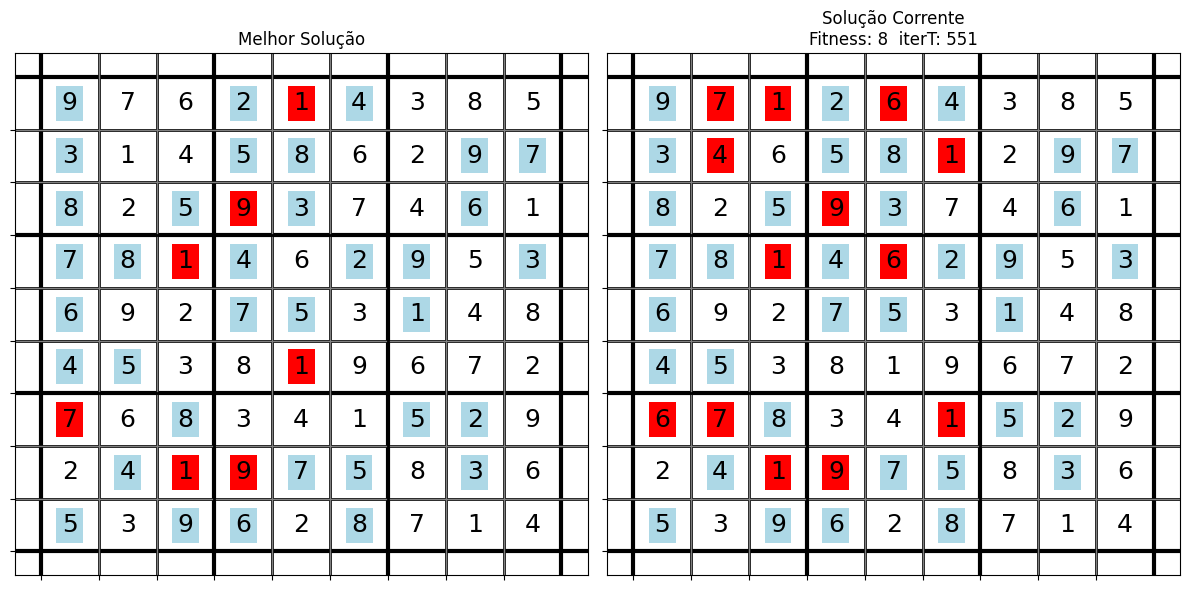

In [18]:
#@title video sem gpt
import random
from math import exp
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def draw_sudoku_for_video(best: SudokuSolver = None, curr: SudokuSolver = None, iterT = 0):
    matrix1 = best.board
    matrix2 = curr.board

    fig = plt.figure(figsize=(12, 6))

    ax1 = plt.subplot(1, 2, 1)
    ax1.set_xticks(np.arange(0, 9, 1))
    ax1.set_yticks(np.arange(0, 9, 1))
    ax1.set_xticklabels([])
    ax1.set_yticklabels([])
    ax1.grid(color='black', linestyle='-', linewidth=2)
    ax1.set_title('Melhor Solução')

    for i in range(9):
        for j in range(9):
            value = matrix1[i][j]
            if value != 0:
                if value is None:
                    ax1.text(j + 0.5, 8 - i + 0.5, ' ', va='center', ha='center', fontsize=18)
                else:
                    if best.fixed_cells[i][j]:
                        ax1.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18,
                                color='black', bbox=dict(facecolor='lightblue', edgecolor='none'))
                    else:
                        if best.have_duplicates_row_col((i, j), matrix1[i][j], matrix1) > 2:
                            ax1.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18,
                                    bbox=dict(facecolor='red', edgecolor='none'))
                        else:
                            ax1.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18)

    for i in range(0, 10, 3):
        ax1.axhline(i, color='black', linewidth=3)
        ax1.axvline(i, color='black', linewidth=3)

    for i in range(1, 9):
        if i % 3 == 0:
            ax1.axhline(i, color='black', linewidth=2)
            ax1.axvline(i, color='black', linewidth=2)
        else:
            ax1.axhline(i, color='gray', linewidth=1)
            ax1.axvline(i, color='gray', linewidth=1)

    ax2 = plt.subplot(1, 2, 2)
    ax2.set_xticks(np.arange(0, 9, 1))
    ax2.set_yticks(np.arange(0, 9, 1))
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])
    ax2.grid(color='black', linestyle='-', linewidth=2)
    ax2.set_title(f'Solução Corrente\nFitness: {curr.fit()}  iterT: {iterT}')

    for i in range(9):
        for j in range(9):
            value = matrix2[i][j]
            if value != 0:
                if value is None:
                    ax2.text(j + 0.5, 8 - i + 0.5, ' ', va='center', ha='center', fontsize=18)
                else:
                    if curr.fixed_cells[i][j]:
                        ax2.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18,
                                color='black', bbox=dict(facecolor='lightblue', edgecolor='none'))
                    else:
                        if curr.have_duplicates_row_col((i, j), matrix2[i][j], matrix2) > 2:
                            ax2.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18,
                                    bbox=dict(facecolor='red', edgecolor='none'))
                        else:
                            ax2.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18)

    for i in range(0, 10, 3):
        ax2.axhline(i, color='black', linewidth=3)
        ax2.axvline(i, color='black', linewidth=3)

    for i in range(1, 9):
        if i % 3 == 0:
            ax2.axhline(i, color='black', linewidth=2)
            ax2.axvline(i, color='black', linewidth=2)
        else:
            ax2.axhline(i, color='gray', linewidth=1)
            ax2.axvline(i, color='gray', linewidth=1)

    plt.tight_layout()

    return fig



def sudokuSA_video(solver: SudokuSolver, SA_MAX=2500, temperature=140, cooling_rate=0.80):
    best_state = solver.copy()
    b_fit = best_state.fit()
    iterT = 0

    curr_state = solver.copy()

    freezing_temperature = 0.5

    if not os.path.exists('sudoku_video'):
        os.mkdir('sudoku_video')

    video_output = cv2.VideoWriter('./sudoku_video/sudoku_video.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 4.0, (1200, 600))

    iter_sem_melhora = 0

    while temperature > freezing_temperature:
        for i in range(SA_MAX):
            if iter_sem_melhora > 100:
                print(f'Bateu em um platô de {iter_sem_melhora} iterações sem melhora, reduzindo a temperatura')
                break
            iterT += 1
            iter_sem_melhora += 1

            v = curr_state.make_all_grids_neighboor_exchange()

            v_best = []
            v_best_fit = 100

            for j in v:
                j_fit = fitness(j)
                if j_fit < v_best_fit:
                    v_best = [row[:] for row in j]
                    v_best_fit = j_fit

            vn = SudokuSolver(3, 3, v_best)
            vn.fixed_cells = curr_state.fixed_cells

            c_fit = curr_state.fit()
            v_fit = vn.fit()

            if v_fit < c_fit:
                curr_state = vn.copy()
                c_fit = v_fit
                iter_sem_melhora = 0
                if c_fit < b_fit:
                    best_state = curr_state.copy()
                    b_fit = c_fit
            elif random.random() < exp((curr_state.fit() - vn.fit()) / temperature) and c_fit != v_fit:
                curr_state = vn.copy()
                c_fit = v_fit
                iter_sem_melhora = 0

            
            fig = draw_sudoku_for_video(best= best_state, curr= curr_state, iterT= iterT)
            fig.canvas.draw()
            video_output.write(cv2.cvtColor(np.array(fig.canvas.renderer.buffer_rgba()), cv2.COLOR_RGBA2BGR))
            plt.close()

            if c_fit == 0:
                break
        if b_fit == 0:
            break
        temperature *= cooling_rate
        print(f'Temperature: {temperature}')
    video_output.release()

    return best_state

nome_arquivo = "./instancias/facil (0.3)/instancia0.txt"
puzzle = read_file(nome_arquivo)


SA_MAX= 800
TEMPERATURE= 600
COOLING_RATE= 0.95

# {'SA_MAX': 800, 'TEMPERATURE': 600, 'COOLING_RATE': 0.95},
solver = SudokuSolver(3,3,puzzle)
solver.greedy_solution()
# draw_sudoku(solver)
sudokuSA_video(solver, SA_MAX, TEMPERATURE, COOLING_RATE)


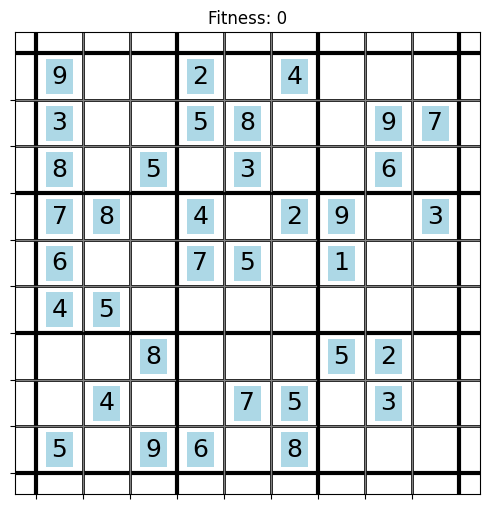

Fitness: 36
[9, 6, 7, 2, 7, 4, 2, 4, 3]
[3, 1, 4, 5, 8, 1, 1, 9, 7]
[8, 2, 5, 9, 3, 6, 5, 6, 8]
[7, 8, 1, 4, 6, 2, 9, 7, 3]
[6, 2, 9, 7, 5, 9, 1, 8, 6]
[4, 5, 3, 3, 8, 1, 4, 2, 5]
[3, 1, 8, 2, 4, 9, 5, 2, 4]
[2, 4, 7, 1, 7, 5, 8, 3, 6]
[5, 6, 9, 6, 3, 8, 7, 1, 9]
Temperature: 570.00
c-fit == 0


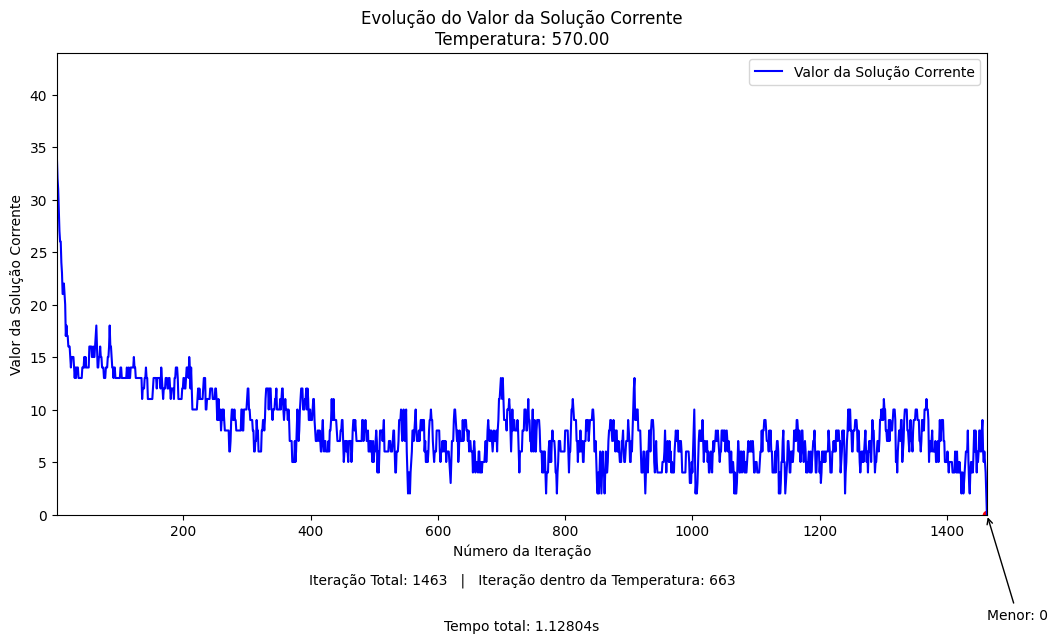

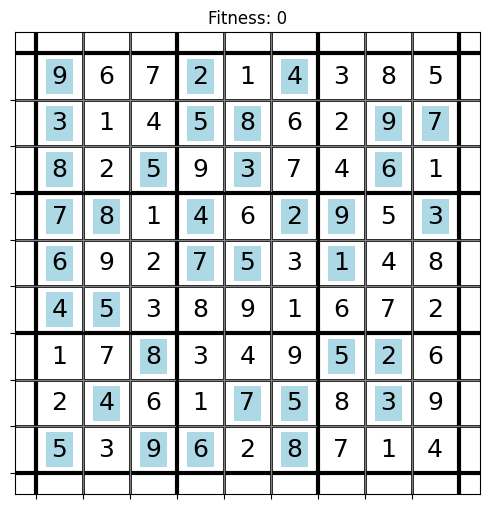

In [8]:
#@title Rodar apenas 1 instancia
nome_arquivo = "./instancias/facil (0.3)/instancia0.txt"
puzzle = read_file(nome_arquivo)


SA_MAX= 800
TEMPERATURE= 600
COOLING_RATE= 0.95

# {'SA_MAX': 800, 'TEMPERATURE': 600, 'COOLING_RATE': 0.95},
solver = SudokuSolver(3,3,puzzle)
draw_sudoku(solver)
solver.random_solution()
solver.show()
solver = sudokuSA_graf(solver, SA_MAX=SA_MAX, temperature=TEMPERATURE, cooling_rate=COOLING_RATE)
draw_sudoku(solver)

In [ ]:
import time

with open('resultados_facil_greedy_4-single.txt', 'w') as f:
    for i in range(300):
        nome_arquivo = f"./instancias/facil (0.3)/instancia{i}.txt"
        puzzle = read_file(nome_arquivo)

        SA_MAX = 800
        TEMPERATURE = 600
        COOLING_RATE = 0.95

        solver = SudokuSolver(3, 3, puzzle)
        solver.random_solution()
        start = time.time()
        try:
            solver, final_fit = sudokuSA(solver, SA_MAX=SA_MAX, temperature=TEMPERATURE, cooling_rate=COOLING_RATE)
            end = time.time()
            f.write(f'{i} {final_fit} {end - start}\n')
            f.flush()  # Grava os dados imediatamente no arquivo
            print(f'{i} {final_fit} {end - start}')
        except Exception as e:
            print(f'Ocorreu um erro na iteração {i}: {str(e)}')


## Valores para instancias faceis

In [9]:
import threading

class MyThread(threading.Thread):
    def __init__(self, instance_range, SA_MAX, TEMPERATURE, COOLING_RATE):
        threading.Thread.__init__(self)
        self.instance_range = instance_range
        self.SA_MAX = SA_MAX
        self.TEMPERATURE = TEMPERATURE
        self.COOLING_RATE = COOLING_RATE

        print(f'Thread {self.name} iniciada com as instâncias {instance_range}')


    def run(self):
        # Lógica da sua thread
        all_values = []
        for i in self.instance_range:
            print(f'Instância {i} iniciada pela thread {self.name}, faltam {self.instance_range.stop - i}')
            nome_arquivo = f"./instancias/dificil (0.9)/instancia{i}.txt"
            puzzle = read_file(nome_arquivo)

            solver = SudokuSolver(3, 3, puzzle)
            solver.random_solution()
            start = time.time()
            try:
                solver, final_fit = sudokuSA(solver, SA_MAX=self.SA_MAX, temperature=self.TEMPERATURE, cooling_rate=self.COOLING_RATE)
                end = time.time()
                with open('resultados_dificil_1_greedy.txt', 'a') as f:
                    f.write(f'{i} {final_fit} {end - start}\n')
                    f.flush()  # Grava os dados imediatamente no arquivo
                # print(f'{i} {final_fit} {end - start}\n')
                all_values.append((i, final_fit, end - start))
            except Exception as e:
                print(f'Ocorreu um erro na iteração {i}: {str(e)}')
                all_values.append((i, None, None))
        return all_values

In [ ]:
SA_MAX = 800
TEMPERATURE = 600
COOLING_RATE = 0.95

threads: List[MyThread] = []
instances_per_thread = 19
total_instances = 300

all_values = []

for i in range(16):
    start_instance = i * instances_per_thread
    end_instance = min((i + 1) * instances_per_thread, total_instances)
    instance_range = range(start_instance, end_instance)
    
    thread = MyThread(instance_range, SA_MAX, TEMPERATURE, COOLING_RATE)
    threads.append(thread)
    thread.start()


for thread in threads:
    thread.join()
    # all_values += thread.run()


In [ ]:
#@title Tentando encontrar bons parametros
import matplotlib.pyplot as plt
nome_arquivo = "./instancias/facil (0.3)/instancia0.txt"
puzzle = read_file(nome_arquivo)

def search_parameters(puzzle, parameter_sets):
    results = []
    for params in parameter_sets:
        SA_MAX = params['SA_MAX']
        TEMPERATURE = params['TEMPERATURE']
        COOLING_RATE = params['COOLING_RATE']

        solver = SudokuSolver(3, 3, puzzle)
        solver.greedy_solution()
        solver = sudokuSA(solver, SA_MAX=SA_MAX, temperature=TEMPERATURE, cooling_rate=COOLING_RATE)

        result = solver.fit()  # Medida de qualidade da solução (pode ser adaptada ao seu caso)
        results.append(result)

    return results


def plot_results(parameter_sets, results):
    x = range(len(parameter_sets))

    plt.plot(x, results, 'o-')
    plt.xlabel('Conjunto de Parâmetros')
    plt.ylabel('Resultado')
    plt.title('Busca de Parâmetros')
    plt.xticks(x, [str(i) for i in range(len(parameter_sets))])  # Mostra o índice do conjunto como legenda
    plt.tight_layout()
    plt.show()


# Defina seus conjuntos de parâmetros para a busca
parameter_sets = [
    {'SA_MAX': 400, 'TEMPERATURE': 200, 'COOLING_RATE': 0.75},
    {'SA_MAX': 500, 'TEMPERATURE': 300, 'COOLING_RATE': 0.8},
    {'SA_MAX': 600, 'TEMPERATURE': 400, 'COOLING_RATE': 0.85},
    {'SA_MAX': 700, 'TEMPERATURE': 500, 'COOLING_RATE': 0.9},
    {'SA_MAX': 800, 'TEMPERATURE': 600, 'COOLING_RATE': 0.95},
    {'SA_MAX': 900, 'TEMPERATURE': 700, 'COOLING_RATE': 0.75},
    {'SA_MAX': 1000, 'TEMPERATURE': 800, 'COOLING_RATE': 0.8},
    {'SA_MAX': 1100, 'TEMPERATURE': 900, 'COOLING_RATE': 0.85},
    {'SA_MAX': 1200, 'TEMPERATURE': 1000, 'COOLING_RATE': 0.9},
    {'SA_MAX': 1300, 'TEMPERATURE': 1100, 'COOLING_RATE': 0.95},
    # Adicione mais conjuntos de parâmetros conforme necessário
]

# Realize a busca de parâmetros e obtenha os resultados
results = search_parameters(puzzle, parameter_sets)

# Plote os resultados
plot_results(parameter_sets, results)



In [ ]:
#@title BACKUP SA
#@title Simulated Anneling for solving sudoku
import copy

def sudokuSA(solver: SudokuSolver, SA_MAX=2500, temperature=140, cooling_rate=0.80, iter_t_max=100):
  solver.greedy_solution()
  best_state = copy.copy(solver)
  best_fit = solver.fit()
  # print(best_fit)

  curr_state = copy.copy(solver)
  curr_fit = best_fit

  for iteration in range(SA_MAX):

    n_solver = copy.copy(curr_state)
    neighboorhood = n_solver.make_neighboorhood_inversion_row()

    for i, n in enumerate(neighboorhood):
      if n_solver.fit() < n.fit():
        n_solver = copy.copy(n)

    if n_solver.fit() < curr_fit:
      # print(f'mudou para de {curr_fit} para {neighboor_fit}')
      curr_state = copy.copy(n_solver)
      curr_fit = n_solver.fit()
    elif n_solver.fit() != curr_fit and random.random() < math.exp(-((curr_fit - n_solver.fit()) / temperature)):
      # print(f'mudou para de {curr_fit} para {neighboor_fit} na cagada')
      curr_state = copy.copy(n_solver)
      curr_fit = n_solver.fit()

    if curr_fit < best_fit:
      best_state = copy.copy(curr_state)
      best_fit = curr_fit

    temperature *= cooling_rate
    # print(f'Temperature: {temperature}')
  print(f"fitness: {best_state.fit()}")
  solver = best_state
  return best_state
